In [1]:
import numpy as np
import pandas as pd
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [2]:
#loading test sets
train_X = joblib.load("data/processed/train_X.joblib")
train_y = joblib.load("data/processed/train_y.joblib")

test_X = joblib.load("data/processed/test_X.joblib")
test_y = joblib.load("data/processed/test_y.joblib")

multi_train_X = joblib.load("data/processed/multi_train_X.joblib")
multi_train_y = joblib.load("data/processed/multi_train_y.joblib")

multi_val_X = joblib.load("data/processed/multi_val_X.joblib")
multi_val_y = joblib.load("data/processed/multi_val_y.joblib")


Test Set Evaluation:
Accuracy: 0.9947
Precision: 0.9945
Recall: 0.9947
F1-Score: 0.9945


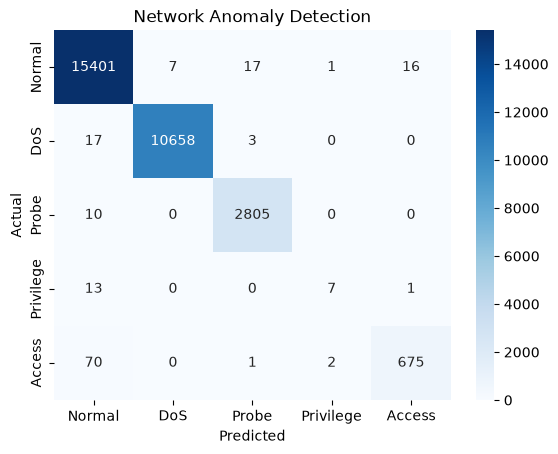

Classification Report for Test Set:
              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00     15442
         DoS       1.00      1.00      1.00     10678
       Probe       0.99      1.00      0.99      2815
   Privilege       0.70      0.33      0.45        21
      Access       0.98      0.90      0.94       748

    accuracy                           0.99     29704
   macro avg       0.93      0.85      0.88     29704
weighted avg       0.99      0.99      0.99     29704



In [3]:
# Final evaluation on the test set
rf_model_multi = RandomForestClassifier(random_state=1337)
rf_model_multi.fit(multi_train_X, multi_train_y)
test_multi_predictions = rf_model_multi.predict(test_X)
test_accuracy = accuracy_score(test_y, test_multi_predictions)
test_precision = precision_score(test_y, test_multi_predictions, average='weighted')
test_recall = recall_score(test_y, test_multi_predictions, average='weighted')
test_f1 = f1_score(test_y, test_multi_predictions, average='weighted')
print("\nTest Set Evaluation:")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1-Score: {test_f1:.4f}")

# Confusion Matrix for Test Set
test_conf_matrix = confusion_matrix(test_y, test_multi_predictions)
class_labels = ['Normal', 'DoS', 'Probe', 'Privilege', 'Access']
sns.heatmap(test_conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('Network Anomaly Detection')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report for Test Set
print("Classification Report for Test Set:")
print(classification_report(test_y, test_multi_predictions, target_names=class_labels))